# Input

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import numpy as np
import seaborn as sns

import pandas as pd
import matplotlib.patches as mpatches

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import PLOTS_DIR, base_dir, aging_clock_train_datasets, cell_types, datasets_all, SAVE_DIR, \
        palette_datasets_pretty, surrogate_names, colors_blind,  palette_cell_types

from ciim.src.utils.util import  retrieve_net_consensus

# Import from GRNimmuneClock package
import sys
sys.path.insert(0, '../GRNimmuneClock')
from grnimmuneclock import predict_age

# Import plotting functions
from ciim.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' 
tune_model = True
create_smoothed_data = True
only_targets = True
temp_dir = f'{SAVE_DIR}/temp/'
plt.rcParams["font.family"] = "Arial"
cell_types = ['CD4T', 'CD8T'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
train_datasets = aging_clock_train_datasets
n_cell_types = len(cell_types)
version = 'all_data'

def get_all_predictions(cell_types, evaluate_datasets, version='all_data'):
    """Get predictions for all cell types and datasets."""
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{SAVE_DIR}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                # Use predict_age from GRNimmuneClock
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs
print(train_datasets)

['data1', 'data7_allTPs_jalil']


# Calculate feature space using consensus GRNs -> smoothened

In [25]:
# datasets = ['op'] + datasets_drug_perturbation + datasets_all + datasets_disease  #'parsebioscience' 'ibd',
datasets = datasets_all
datasets = ['soundlife']
if False:
    adata_integrated = ad.read_h5ad(f'{SAVE_DIR}/gene_expression_smoothed/adata_latent_corrected.h5ad')
    for dataset in datasets:
        for cell_type in cell_types:
            print(f'Preparing data for {dataset} {cell_type} {feature_type}')
            adata = adata_integrated[(adata_integrated.obs['dataset'] == dataset)&(adata_integrated.obs['cell_type'] == cell_type)].copy()
            adata.write(f'{SAVE_DIR}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')
if create_smoothed_data:
    from grnimmuneclock import format_data
    for dataset in datasets:
        for cell_type in cell_types:
            print(f'Preparing data for {dataset} {cell_type} {feature_type}')
            adata_s = format_data([dataset], cell_type=cell_type, data_type=data_type, only_ctr=False, only_targets=only_targets)
            # adata_s = adata[(adata.obs['dataset'] == dataset)&(adata.obs['cell_type'] == cell_type)].copy()
            obs = adata_s.obs.dropna(axis=1, how='all')
            adata_s.obs = obs
            for col in adata_s.obs.columns:
                if adata_s.obs[col].dtype == "object":
                    adata_s.obs[col] = adata_s.obs[col].astype(str)

            adata_s.write(f'{SAVE_DIR}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')

Preparing data for soundlife CD4T gene_expression
Datasets in merged adata: ['soundlife']
Cell types in merged adata: ['CD4T']
Categories (1, object): ['CD4T']
Datasets in merged adata: ['soundlife']
Cell types in merged adata: ['CD4T']
Categories (1, object): ['CD4T']
Preparing data for soundlife CD8T gene_expression
Preparing data for soundlife CD8T gene_expression
Datasets in merged adata: ['soundlife']
Cell types in merged adata: ['CD8T']
Categories (1, object): ['CD8T']
Datasets in merged adata: ['soundlife']
Cell types in merged adata: ['CD8T']
Categories (1, object): ['CD8T']


# Feature analysis

In [53]:
features_dict = {}
for cell_type in cell_types:
    adata = ad.read_h5ad(f'{SAVE_DIR}/{feature_type}_smoothed/data1_{cell_type}_{data_type}.h5ad')
    # min_degree = min(len(aging_clock_train_datasets), 4)
    # net = retrieve_net_consensus(datasets_all, cell_type)
    features_dict[cell_type] = adata.var_names.tolist() # net[net['degree']>=min_degree]['feature'].tolist()

## Intersection of features

In [56]:
from grn_benchmark.src.exp_analysis.helper import plot_interactions, create_interaction_df

interaction_main_df = create_interaction_df(features_dict)

['CD8T', 'CD4T']


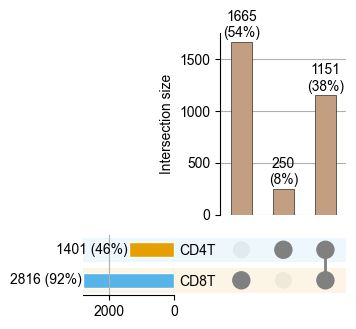

In [57]:
aa = plot_interactions(interaction_main_df, min_subset_size=100, min_degree=1, color_map=palette_cell_types)

plt.savefig(f'{PLOTS_DIR}/interactions_targets.png', dpi=300, transparent=True, bbox_inches='tight')
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

## Pathway analysis

In [58]:
import gseapy as gp
from gseapy import barplot, dotplot
all_genes = np.loadtxt(f'{base_dir}/prior/gene_names.txt', dtype=str)
print(all_genes)
gene_sets = 'MSigDB_Hallmark_2020'
res2d_store = []
for cell_type, genes in features_dict.items():
    rr = gp.enrichr(gene_list=list(genes),
                gene_sets=gene_sets, #, 'KEGG_2021_Human'
                organism='human', 
                outdir=None, 
                cutoff=1,
                # background=list(all_genes),
                )
    res2d = rr.res2d
    res2d.rename(columns={'Adjusted P-value': 'FDR'}, inplace=True)
    filter_col = 'FDR' #'FDR q-val'
    res2d = res2d[res2d[filter_col]<0.05]
    if res2d.shape[0] == 0:
        continue
    print(res2d.shape)
    res2d['cell_type'] = cell_type
    res2d_store.append(res2d)

pathway_scores = pd.concat(res2d_store)

pathway_scores['n_genes'] = pathway_scores['Genes'].str.split(';').apply(len)
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])

['DDX11L16' 'DDX11L1' 'WASH7P' ... 'ENSG00000149656' 'ENSG00000310230'
 'IQSEC3P3']
(34, 10)
(34, 10)
(34, 10)
(34, 10)


In [59]:
pathway_scores[pathway_scores['cell_type']=='CD4T']['Term'].unique()

array(['Interferon Gamma Response', 'TNF-alpha Signaling via NF-kB',
       'Interferon Alpha Response', 'IL-2/STAT5 Signaling',
       'Allograft Rejection', 'Apoptosis', 'Myc Targets V1', 'Hypoxia',
       'p53 Pathway', 'Inflammatory Response', 'mTORC1 Signaling',
       'IL-6/JAK/STAT3 Signaling', 'Complement', 'Androgen Response',
       'UV Response Dn', 'PI3K/AKT/mTOR  Signaling', 'KRAS Signaling Up',
       'UV Response Up', 'Estrogen Response Early',
       'Unfolded Protein Response', 'TGF-beta Signaling',
       'heme Metabolism', 'Mitotic Spindle', 'Adipogenesis',
       'Reactive Oxygen Species Pathway', 'Estrogen Response Late',
       'Apical Junction', 'Cholesterol Homeostasis', 'Protein Secretion',
       'G2-M Checkpoint', 'E2F Targets',
       'Epithelial Mesenchymal Transition', 'Oxidative Phosphorylation',
       'Glycolysis'], dtype=object)

In [8]:
pathway_scores[pathway_scores['cell_type']=='CD4T'].head()

,Gene_set,Term,Overlap,P-value,FDR,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,cell_type,n_genes,neg_log10_adj_pval
0,MSigDB_Hallmark_2020,Interferon Gamma Response,89/200,1.822964e-49,8.932525e-48,0,0,11.298561,1267.994604,CDKN1A;SAMD9L;IFITM2;BTG1;EIF4E3;TNFAIP3;UBE2L...,CD4T,89,47.049026
1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,80/200,2.394236e-40,5.865879e-39,0,0,9.325763,850.792552,BTG2;CDKN1A;BTG1;CD83;B4GALT1;PLEK;TNFAIP3;IRS...,CD4T,80,38.231667
2,MSigDB_Hallmark_2020,Interferon Alpha Response,51/97,2.639540e-33,4.311249e-32,0,0,15.236763,1142.981278,IFITM1;SAMD9L;IFITM2;UBE2L6;ADAR;IFI35;IFIT3;I...,CD4T,51,31.365397
3,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,68/199,1.600975e-29,1.961195e-28,0,0,7.191630,476.836383,PHTF2;CD83;GPR65;RORA;SLC2A3;AHR;IKZF2;IKZF4;I...,CD4T,68,27.707479
4,MSigDB_Hallmark_2020,Allograft Rejection,65/200,7.581400e-27,7.429772e-26,0,0,6.654247,400.213699,ITK;GPR65;PRF1;ITGAL;RPL9;CD3D;TNF;ETS1;CCND3;...,CD4T,65,25.129025


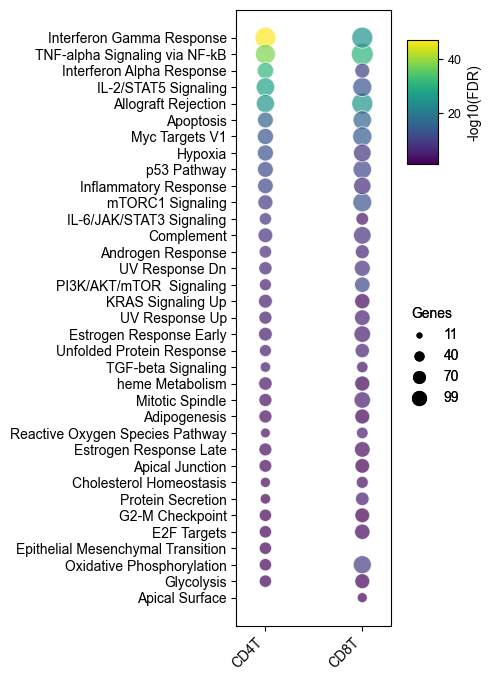

In [60]:
from ciim.src.feature_association.plots import dotplot_category_color
from ciim.src.common import surrogate_names
    
fig, ax = plt.subplots(1, 1, figsize=(2, 8), sharey=True, sharex=True)

pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
show_color_legend = True
show_size_legend = True

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='neg_log10_adj_pval', 
            size_col='n_genes', 
            x='cell_type', 
            y='Term', 
            palette='viridis', 
            sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Genes',
            color_legend_title='-log10(FDR)',
            color_legend_loc=(1.1, 0.75),
            size_legend_loc=(1.05, 0.35),
            size_legend_scale=1,
            y_label='',
            alpha=0.7)
plt.savefig(f'{PLOTS_DIR}/enrichment_targets.png', dpi=300, transparent=True, bbox_inches='tight')

## Time trend of selected genes

In [61]:
from grnimmuneclock import retrieve_function
top_genes_dict = {}
top_weights_dict = {}
top_tfs_dict = {}
top_acts_dict = {}
for cell_type in cell_types:
    model, gene_names = retrieve_function(reg_type, cell_type, data_type, feature_type, version)
    coefs = model.named_steps["ridge"].coef_
    
    abs_coefs = np.abs(coefs)
    top_idx = np.argsort(abs_coefs)[-5:][::-1]
    top_genes = [gene_names[i] for i in top_idx]
    top_genes_dict[cell_type] = top_genes
    top_weights_dict[cell_type] = coefs[top_idx]

    if True: # calculate TF activity
        import decoupler as dc
        net = retrieve_net_consensus(datasets=datasets_all, cell_type=cell_type)
        
        if True: # select top genes
            top_idx = np.argsort(abs_coefs)[-100:][::-1]
            top_genes = [gene_names[i] for i in top_idx]
            gene_names = top_genes
            coefs = coefs[top_idx]
        obs = pd.DataFrame({'sample': [1]})
        var = pd.DataFrame({'genes': gene_names})
        var.index = var['genes']

        X=[[float(c) for c in coefs]]
        adata = ad.AnnData(np.asarray(X), obs=obs, var=var)
        dc.mt.ulm(adata, net, tmin=5)
        tf_acts_df = adata.obsm['score_ulm']
        tf_acts_X = tf_acts_df.values[0]

        abs_acts = np.abs(tf_acts_X)
        tfs = tf_acts_df.columns
        top_idx = np.argsort(abs_acts)[-5:][::-1]
        top_tfs= [tfs[i] for i in top_idx]
 
        top_tfs_dict[cell_type] = top_tfs
        top_acts_dict[cell_type] = tf_acts_X[top_idx]

CD4T
CD8T
CD4T
CD8T
CD4T
CD8T
CD8T


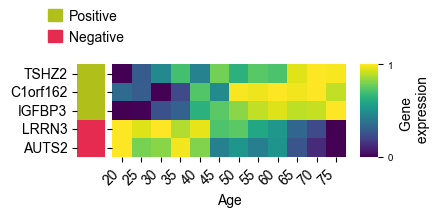

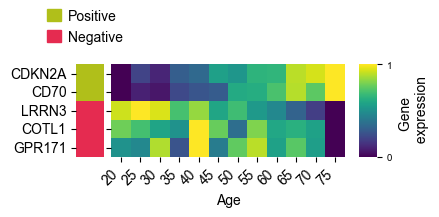

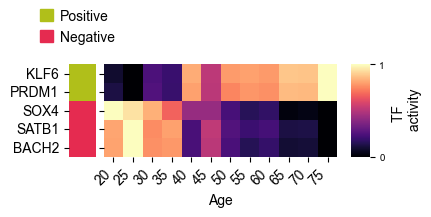

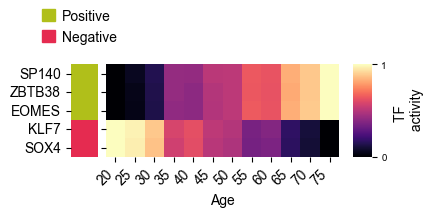

In [62]:
def plot_feature_values(cell_type, features, feature_type, dataset='data1', ax=None, show_cbar=True, type='bulk', 
                                    age_limit=[20, 80], show_ylabels=True):
    from ciim.src.feature_association.helper import retrieve_feature_data, bin_feature_values
    from ciim.src.feature_association.plots import heatplot_age_trend
       
    adata = retrieve_feature_data(dataset=dataset, cell_type=cell_type, type=type, feature_type=feature_type) 
    adata = adata[(adata.obs['age'] > age_limit[0]) & (adata.obs['age'] < age_limit[1])]
    adata = adata[:, adata.var_names.isin(features)]
    assert adata.shape[1]>0, f"Features {features} not found in dataset {dataset} for cell type {cell_type}"

    mean_expr = bin_feature_values(adata)
    # sort the index base on features
    mean_expr = mean_expr.loc[features]
    ages = sorted(mean_expr.columns)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 2))

    heatplot_age_trend(mean_expr[ages], cmap='magma' if feature_type=='tf_activity' else 'viridis', 
                        cbar_title = "Gene \n expression" if feature_type == 'gene_expression' else (
                                    "TF \n activity" if feature_type == 'tf_activity' else "Gene score"
                                ),
                        ax=ax, 
                        show_cbar=show_cbar,
                        cbar_kws={
                            "shrink": 1,
                            "aspect": 5,       # Lower values = thicker colorbar (default is ~20)
                            "fraction": 0.1    # Controls the width space the cbar takes in the figure
                        })
    if not show_ylabels:
        ax.set_yticklabels([])
    ax.set_ylabel('')
    ax.set_xlabel('Age')
from matplotlib.colors import ListedColormap

def wrapper_trend(top_features_dict, top_feature_values_dict, feature_type, dataset='data1'):
    for cell_type, features in top_features_dict.items():
        print(cell_type)
        fig, axes = plt.subplots(1, 2, figsize=(4, 1.2), width_ratios=[.1, 1], gridspec_kw={'wspace':0.05})
        # --- Left: weight sign heatmap ---
        ax = axes[0]
        top_weights = np.sign(top_feature_values_dict[cell_type])  # ±1
        df = pd.DataFrame({'feature': features, 'weight': top_weights})
        df = df.set_index('feature').loc[features]  # enforce order
        # sort df based on sign
        df = df.sort_values(by='weight', ascending=False)
        features = df.index.tolist()
        cmap = ListedColormap(['#E52B50', '#B0BF1A'])
        sns.heatmap(
            df[['weight']],
            cmap=cmap,
            cbar=False,
            ax=ax,
            annot=False )
        ax.set_xlabel("")
        red_patch = mpatches.Patch(color='#E52B50', label='Negative')
        green_patch = mpatches.Patch(color='#B0BF1A', label='Positive')
        ax.legend(handles=[green_patch, red_patch], bbox_to_anchor=(1.7, 1.6), loc='upper right', borderaxespad=0., frameon=False)
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_xticks([])

        ax = axes[1]

        plot_feature_values(cell_type, features, feature_type=feature_type, dataset=dataset, ax=ax, show_cbar=True, type='bulk', 
                                        age_limit=[20, 80], show_ylabels=True)
        ax.set_yticklabels([])
        # plt.title(f'{cell_type}', pad=15, weight='bold')
wrapper_trend(top_genes_dict, top_weights_dict, feature_type='gene_expression', dataset=datasets_all[0])
# plt.savefig(f'{PLOTS_DIR}/top_genes_{cell_type}.png', dpi=300, transparent=True, bbox_inches='tight')
wrapper_trend(top_tfs_dict, top_acts_dict, feature_type='tf_activity', dataset=datasets_all[0])

## Save consensus GRNs for package tutorial

In [63]:
# Generate and save consensus GRNs for the tutorial
import os

# Path to package data directory
package_data_dir = '../GRNimmuneClock/grnimmuneclock/data'
os.makedirs(package_data_dir, exist_ok=True)

# Generate consensus GRNs for CD4T and CD8T
grn_dict = {}
for cell_type in ['CD4T', 'CD8T']:
    print(f"Generating consensus GRN for {cell_type}...")
    net = retrieve_net_consensus(datasets=datasets_all, cell_type=cell_type, min_degree=3)
    grn_dict[cell_type] = net
    
    # Save to CSV in package data directory
    output_path = f'{package_data_dir}/consensus_grn_{cell_type}.csv'
    net.to_csv(output_path, index=False)
    print(f"  Saved to: {output_path}")
    print(f"  Links: {len(net)}")
    print(f"  Sources (TFs): {net['source'].nunique()}")
    print(f"  Targets: {net['target'].nunique()}\n")

print("✓ Consensus GRNs saved successfully!")

Generating consensus GRN for CD4T...
  Saved to: ../GRNimmuneClock/grnimmuneclock/data/consensus_grn_CD4T.csv
  Links: 12084
  Sources (TFs): 164
  Targets: 1429

Generating consensus GRN for CD8T...
  Saved to: ../GRNimmuneClock/grnimmuneclock/data/consensus_grn_CD8T.csv
  Links: 45552
  Sources (TFs): 262
  Targets: 2928

✓ Consensus GRNs saved successfully!


# Train the model

In [29]:
if True:
    # Use GRNimmuneClock training module instead of subprocess
    from pathlib import Path
    from grnimmuneclock import train_aging_clock
    
    for cell_type in cell_types:
        print(f"\n{'='*60}")
        print(f"Training {cell_type} aging clock")
        print(f"{'='*60}")
        
        model, predictions, adata_train = train_aging_clock(
            cell_type=cell_type,
            datasets=train_datasets,
            feature_type=feature_type,
            data_type=data_type,
            reg_type=reg_type,
            tune_model=tune_model,
            age_limit=20,
            save_dir=Path(SAVE_DIR),
            output_dir=Path(SAVE_DIR) / 'clock',
            version=version,
            verbose=True
        )
        
        # Save training data with predictions
        adata_train.write(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        
        print(f"\n✓ {cell_type} model trained and saved")
        print(f"  Training R²: {adata_train.obs[['age', 'predicted_age']].corr().iloc[0,1]**2:.3f}")



Training CD4T aging clock
Training aging clock for CD4T
Datasets: ['data1', 'data7_allTPs_jalil']


[I 2025-11-30 19:42:14,053] A new study created in memory with name: no-name-162b0d57-fa6e-405d-805f-a05c7f09d784


Merged data shape: (1289, 1395)
Datasets: {'data1': 976, 'data7_allTPs_jalil': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-30 19:42:14,287] Trial 0 finished with value: -3.8656554765397093 and parameters: {'alpha': 0.062250276412834316}. Best is trial 0 with value: -3.8656554765397093.
[I 2025-11-30 19:42:14,330] Trial 1 finished with value: -1.2318856348980236 and parameters: {'alpha': 3.853243858066818}. Best is trial 1 with value: -1.2318856348980236.
[I 2025-11-30 19:42:14,359] Trial 2 finished with value: 0.5130692390614342 and parameters: {'alpha': 57.03774356974917}. Best is trial 2 with value: 0.5130692390614342.
[I 2025-11-30 19:42:14,388] Trial 3 finished with value: -0.013181337909520696 and parameters: {'alpha': 10.910443580297805}. Best is trial 2 with value: 0.5130692390614342.
[I 2025-11-30 19:42:14,437] Trial 4 finished with value: -3.9112807080748286 and parameters: {'alpha': 0.025422118417662558}. Best is trial 2 with value: 0.5130692390614342.
[I 2025-11-30 19:42:14,465] Trial 5 finished with value: -2.4124249965511106 and parameters: {'alpha': 1.5907466001136557}. Best is tri

[I 2025-11-30 19:42:15,900] A new study created in memory with name: no-name-75814f0a-f9d9-41e0-9a90-fab2c182a69c


Model saved to /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output/clock/CD4T_bulk_gene_expression_ridge_all_data_model.pkl
Features saved to /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output/clock/feature_names_CD4T_bulk_gene_expression_all_data.txt

✓ CD4T model trained and saved
  Training R²: 0.866

Training CD8T aging clock
Training aging clock for CD8T
Datasets: ['data1', 'data7_allTPs_jalil']
Merged data shape: (1289, 2790)
Datasets: {'data1': 976, 'data7_allTPs_jalil': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-30 19:42:16,008] Trial 0 finished with value: 0.5022045409534218 and parameters: {'alpha': 5.213327777481288}. Best is trial 0 with value: 0.5022045409534218.
[I 2025-11-30 19:42:16,085] Trial 1 finished with value: 0.49909142812204166 and parameters: {'alpha': 1.1360560689976114}. Best is trial 0 with value: 0.5022045409534218.
[I 2025-11-30 19:42:16,138] Trial 2 finished with value: 0.502230268517293 and parameters: {'alpha': 5.248498587237026}. Best is trial 2 with value: 0.502230268517293.
[I 2025-11-30 19:42:16,203] Trial 3 finished with value: 0.5413450018944973 and parameters: {'alpha': 195.1446402290578}. Best is trial 3 with value: 0.5413450018944973.
[I 2025-11-30 19:42:16,259] Trial 4 finished with value: 0.5025369818182519 and parameters: {'alpha': 5.669758417722425}. Best is trial 3 with value: 0.5413450018944973.
[I 2025-11-30 19:42:16,305] Trial 5 finished with value: 0.5374495137320205 and parameters: {'alpha': 590.73007436815}. Best is trial 3 with value: 0.

# Cross-validation performance

In [30]:
def get_all_predictions(cell_types, evaluate_datasets, version='all_data'):
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{SAVE_DIR}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs
from ciim.src.common import test_datasets
obs = get_all_predictions(cell_types, test_datasets)

In [31]:
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

# obs: DataFrame with at least ['cell_type','dataset','age','predicted_age']

fold_scores = {}
all_preds = []

for (cell_type_name, dataset_name), df in obs.groupby(['cell_type', 'dataset']):
    y_true = df['age'].values
    y_pred = df['predicted_age'].values

    # Compute metrics
    spearman_corr = spearmanr(y_true, y_pred).correlation
    r2 = r2_score(y_true, y_pred)

    # Store scores using a tuple as key
    fold_scores[(cell_type_name, dataset_name)] = {
        'spearman': round(spearman_corr, 3),
        'r2': round(r2, 3)
    }

    # Keep predictions with cell_type and dataset columns
    pred_df = df.copy()
    all_preds.append(pred_df)

# Convert scores dict to DataFrame
scores_df = pd.DataFrame.from_dict(fold_scores, orient='index')
scores_df.index = pd.MultiIndex.from_tuples(scores_df.index, names=['cell_type', 'dataset'])

# Concatenate predictions
predictions_df = pd.concat(all_preds)


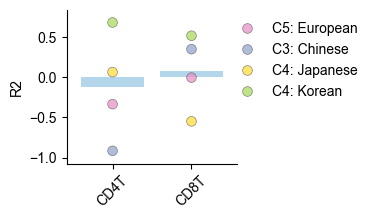

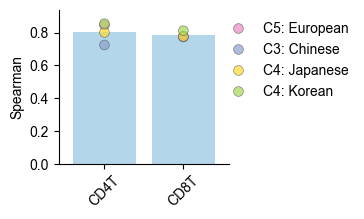

In [32]:
scores_df = scores_df.reset_index()  # make cell_type and dataset columns

# Optionally map dataset names to prettier versions
if 'surrogate_names' in globals():
    scores_df['dataset'] = scores_df['dataset'].map(lambda name: surrogate_names.get(name, name))

def plot_scores(cv_scores, metric, figsize=[2.5, 2]):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Strip plot (scatter of individual dataset scores)
    sns.stripplot(
        data=cv_scores, x='cell_type', y=metric,
        hue='dataset', dodge=False, jitter=False, s=7,
        alpha=0.7, linewidth=0.5, edgecolor='gray', palette=palette_datasets_pretty,
        ax=ax
    )

    # Bar plot (mean scores per cell type)
    sns.barplot(
        data=cv_scores, x='cell_type', y=metric,
        estimator='mean', errorbar=None,
        color=colors_blind[1], alpha=0.5, ax=ax
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    # Legend
    ax.legend(title='', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    ax.set(
        ylabel=metric.capitalize(),
        xlabel=''
    )
    return fig

# Plot R²
scores_df['cell_type'] = pd.Categorical(scores_df['cell_type'], categories=cell_types, ordered=True)
fig = plot_scores(scores_df, 'r2', figsize=(2.2, 2))
fig.savefig(f'{PLOTS_DIR}/{data_type}_{feature_type}_{reg_type}_celltype_dataset_r2.png',
            bbox_inches='tight', dpi=300, transparent=True)

# Plot Spearman
fig = plot_scores(scores_df, 'spearman', figsize=(2.2, 2))
fig.savefig(f'{PLOTS_DIR}/{data_type}_{feature_type}_{reg_type}_celltype_dataset_spearman.png',
            bbox_inches='tight', dpi=300, transparent=True)

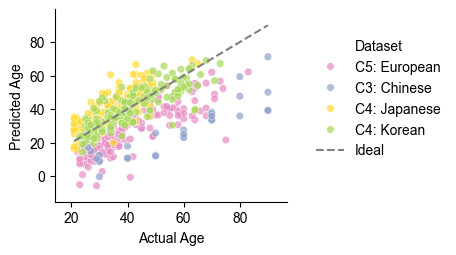

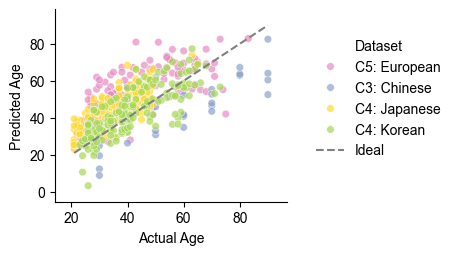

In [33]:
predictions_df['dataset'] = predictions_df['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in cell_types:
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharey=True)

    df = predictions_df[predictions_df['cell_type'] == cell_type]

    plot_scatter_age_vs_predictedAge(df, dataset='', ax=ax, hue='dataset', palette=palette_datasets_pretty, s=30, alpha=0.7)
    ax.legend(loc=(1.1, .2), frameon=False, title='Dataset')
    plt.savefig(f'{PLOTS_DIR}/clock_training_datasets.png', bbox_inches='tight', dpi=300, transparent=True)

#  Compare to wenchao's results

In [34]:
W_train_datasets = ['data1', 'data7_allTPs_jalil'] # we only use these datasets for training for a fair comparision
test_datasets = ['SLE_European', 'data13_Korean']

version = 'comparitive'

In [36]:
if True:
    # Use GRNimmuneClock training module instead of subprocess
    from pathlib import Path
    from grnimmuneclock import train_aging_clock
    
    for cell_type in cell_types:
        print(f"\n{'='*60}")
        print(f"Training {cell_type} aging clock for Wenchao comparison")
        print(f"{'='*60}")
        
        model, predictions, adata_train = train_aging_clock(
            cell_type=cell_type,
            datasets=W_train_datasets,
            feature_type=feature_type,
            data_type=data_type,
            reg_type=reg_type,
            tune_model=tune_model,
            age_limit=20,
            save_dir=Path(SAVE_DIR),
            output_dir=Path(SAVE_DIR) / 'clock',
            version=version,
            verbose=True
        )
        
        # Save training data with predictions
        adata_train.write(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        
        print(f"\n✓ {cell_type} model trained and saved")
        print(f"  Training R²: {adata_train.obs[['age', 'predicted_age']].corr().iloc[0,1]**2:.3f}")


[I 2025-11-30 19:53:40,900] A new study created in memory with name: no-name-b0543c19-b2bf-4f5d-b66a-c84518ed67fc



Training CD4T aging clock for Wenchao comparison
Training aging clock for CD4T
Datasets: ['data1', 'data7_allTPs_jalil']
Merged data shape: (1289, 1395)
Datasets: {'data1': 976, 'data7_allTPs_jalil': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-30 19:53:41,173] Trial 0 finished with value: -3.4672248042827656 and parameters: {'alpha': 0.40679476030248024}. Best is trial 0 with value: -3.4672248042827656.
[I 2025-11-30 19:53:41,212] Trial 1 finished with value: -3.8724793926365333 and parameters: {'alpha': 0.05671021920507786}. Best is trial 0 with value: -3.4672248042827656.
[I 2025-11-30 19:53:41,243] Trial 2 finished with value: -1.8432710804695716 and parameters: {'alpha': 2.4932546014620782}. Best is trial 2 with value: -1.8432710804695716.
[I 2025-11-30 19:53:41,278] Trial 3 finished with value: -1.7196119537670778 and parameters: {'alpha': 2.727836314368185}. Best is trial 3 with value: -1.7196119537670778.
[I 2025-11-30 19:53:41,317] Trial 4 finished with value: 0.29360369371697803 and parameters: {'alpha': 18.654253178844836}. Best is trial 4 with value: 0.29360369371697803.
[I 2025-11-30 19:53:41,353] Trial 5 finished with value: -2.1402852157636096 and parameters: {'alpha': 1.9904800825907205}. Best is tr

[I 2025-11-30 19:53:42,641] A new study created in memory with name: no-name-ac8ce9be-a740-4e62-b852-7b7aa43a741e


Merged data shape: (1289, 2790)
Datasets: {'data1': 976, 'data7_allTPs_jalil': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-30 19:53:42,730] Trial 0 finished with value: 0.4982227213275616 and parameters: {'alpha': 0.057629077463757616}. Best is trial 0 with value: 0.4982227213275616.
[I 2025-11-30 19:53:42,797] Trial 1 finished with value: 0.506107625769351 and parameters: {'alpha': 10.859560508423884}. Best is trial 1 with value: 0.506107625769351.
[I 2025-11-30 19:53:42,868] Trial 2 finished with value: 0.5416033436450457 and parameters: {'alpha': 330.2850198872829}. Best is trial 2 with value: 0.5416033436450457.
[I 2025-11-30 19:53:42,912] Trial 3 finished with value: 0.498285126134831 and parameters: {'alpha': 0.13428779062288987}. Best is trial 2 with value: 0.5416033436450457.
[I 2025-11-30 19:53:42,868] Trial 2 finished with value: 0.5416033436450457 and parameters: {'alpha': 330.2850198872829}. Best is trial 2 with value: 0.5416033436450457.
[I 2025-11-30 19:53:42,912] Trial 3 finished with value: 0.498285126134831 and parameters: {'alpha': 0.13428779062288987}. Best is trial 2 with val

## Get W results on test data

In [42]:
def extract_w_results():
    # - read the results of predictions
    df_store = []
    for dataset in ['C4', 'C5']:
        df = pd.read_csv(f'{SAVE_DIR}/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
        df['dataset'] = 'data13_Korean' if dataset=='C4' else 'SLE_European'
        df_store.append(df)
    df = pd.concat(df_store, axis=0)
    df['donor_age'] = df['donor_id'].astype(str) + '_' + df['age'].astype(str)
    # - format 
    df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type'}, inplace=True)
    df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})
    # - median prediction
    median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
    median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')
    return median_prediction
W_median_prediction = extract_w_results()

## Get our results on test data

In [43]:
predictions_all = get_all_predictions(cell_types, test_datasets, version=version)
predictions_all.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,age_acceleration,batch_info
148,_CD4T_1004_39.0,Female,CD4T,SLE,SLE_European,CD4T,100439,39,1004,SLE,European,1469,False,38.567407,-0.432593,NaN
149,_CD4T_1014_40.0,Female,CD4T,SLE,SLE_European,CD4T,101440,40,1014,SLE,European,988,False,30.481080,-9.518920,NaN
150,_CD4T_1015_54.0,Female,CD4T,SLE,SLE_European,CD4T,101554,54,1015,SLE,European,971,False,40.354984,-13.645016,NaN
151,_CD4T_1019_64.0,Female,CD4T,SLE,SLE_European,CD4T,101964,64,1019,SLE,European,2014,False,52.487534,-11.512466,NaN
152,_CD4T_1039_42.0,Female,CD4T,SLE,SLE_European,CD4T,103942,42,1039,SLE,European,840,False,11.642095,-30.357905,NaN


In [44]:
from grnimmuneclock import evaluate_groupwise_median
test_predictions = predictions_all[(predictions_all['dataset'].isin(test_datasets)) & (predictions_all['condition']=='Healthy')]
test_predictions.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,age_acceleration,batch_info
224,_CD4T_HC-002_27.0,Male,CD4T,Healthy,SLE_European,CD4T,HC-00227,27,HC-002,SLE,European,1532,True,18.714562,-8.285438,NaN
225,_CD4T_HC-006_53.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00653,53,HC-006,SLE,European,2134,True,37.847236,-15.152764,NaN
226,_CD4T_HC-008_48.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00848,48,HC-008,SLE,European,792,True,35.577765,-12.422235,NaN
227,_CD4T_HC-009_27.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00927,27,HC-009,SLE,European,5346,True,12.061536,-14.938464,NaN
228,_CD4T_HC-020_35.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-02035,35,HC-020,SLE,European,1155,True,23.744063,-11.255937,NaN


In [45]:
test_predictions['dataset'].unique()

array(['SLE_European', 'data13_Korean'], dtype=object)

## Calculate the scores

In [46]:
import pandas as pd

all_scores = []

for cell_type in test_predictions['cell_type'].unique():
    for dataset in test_datasets:
        # Your model
        df1 = test_predictions[
            (test_predictions['dataset'] == dataset) & 
            (test_predictions['cell_type'] == cell_type)
        ].copy()
        ss1 = evaluate_groupwise_median(df1)  # returns {'Spearman': ..., 'R2': ...}
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'GRNdrived',
            'Spearman': ss1['Spearman'],
            'R2': ss1['R2']
        })

        # Wenchao's model
        df2 = W_median_prediction[
            (W_median_prediction['dataset'] == dataset) & 
            (W_median_prediction['cell_type'] == cell_type)
        ].copy()
        ss2 = evaluate_groupwise_median(df2)
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'Wenchao',
            'Spearman': ss2['Spearman'],
            'R2': ss2['R2']
        })

# Convert to DataFrame
score_df = pd.DataFrame(all_scores)


## Plot

In [47]:
palette_models = {
    'Wenchao': colors_blind[1], 
    'GRNdrived': colors_blind[0]
}

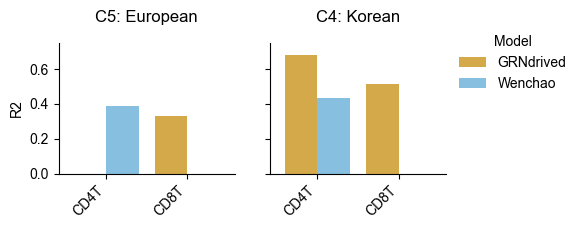

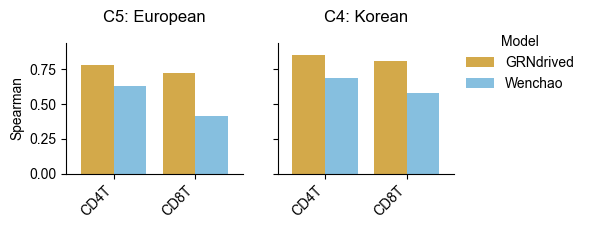

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clip R2 to [0, 1]
score_df['R2'] = score_df['R2'].clip(0, 1)

# Sort datasets for consistent layout
datasets = score_df['dataset'].unique()
n_datasets = len(datasets)

# Plot each metric in a separate figure
for metric in ['R2', 'Spearman']:
    fig, axes = plt.subplots(1, n_datasets, figsize=(2.5 * n_datasets, 1.7), sharey=True)

    if n_datasets == 1:
        axes = [axes]  # Ensure iterable if only one axis

    for ax, dataset in zip(axes, datasets):
        df_plot = score_df[score_df['dataset'] == dataset]

        sns.barplot(
            data=df_plot,
            x='cell_type',
            y=metric,
            hue='model',
            ax=ax,
            alpha=0.8,
            palette=palette_models,
        )   

        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.margins(x=0.1, y=0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.get_legend().remove()
        ax.set_title(f'{surrogate_names[dataset]}', pad=15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # fig.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/clock_comparison_{metric}.png', bbox_inches='tight', dpi=300, transparent=True)


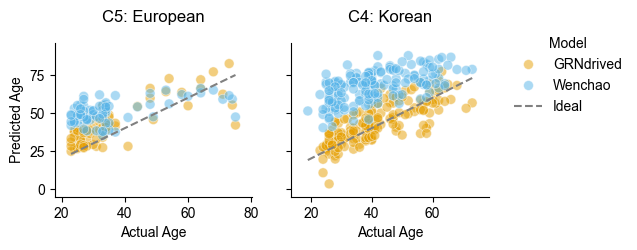

In [49]:
W_median_prediction['model'] = 'Wenchao'
test_predictions['model'] = 'GRNdrived'

obs = pd.concat([test_predictions, W_median_prediction], axis=0)
datasets = obs['dataset'].unique()

for cell_type in ['CD8T']:
    fig, axes = plt.subplots(1, len(datasets), figsize=(2.8*len(datasets), 2), sharey=True)
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, hue='model', palette=palette_models)
        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .5), frameon=False, title='Model')
    plt.savefig(f'{PLOTS_DIR}/clock_comparison_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
    
    # plt.suptitle(cell_type, fontsize=12, weight='bold')
    # plt.tight_layout()

# Disease: SLE

In [32]:
!cd ../ && python src/experiments/clock_analysis.py --dataset SLE_European --analysis-type disease --cell-types CD4T CD8T

Aging Clock Analysis - Disease
Dataset: SLE_European
Analysis type: disease
Feature type: gene_expression
Data type: bulk
Model version: all_data
Cell types: CD4T, CD8T
P-value threshold: 0.05
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/

Loading predictions...
Loaded 300 predictions
Conditions: ['SLE' 'Healthy']


Disease Analysis: SLE_European
Generating age acceleration plot...
Traceback (most recent call last):
  File "/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item


# Perturbation

In [33]:
!cd ../ && python src/experiments/clock_analysis.py --dataset parsebioscience --analysis-type perturbation --cell-types CD4T CD8T

Aging Clock Analysis - Perturbation
Dataset: parsebioscience
Analysis type: perturbation
Feature type: gene_expression
Data type: bulk
Model version: all_data
Cell types: CD4T, CD8T
P-value threshold: 0.05
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/

Loading predictions...
Loaded 2304 predictions
Conditions: ['4-1BBL' 'ADSF' 'APRIL' 'BAFF' 'C3a' 'C5a' 'CD27L' 'CD30L' 'CD40L' 'CT-1'
 'Decorin' 'EGF' 'EPO' 'FGF-beta' 'FLT3L' 'FasL' 'G-CSF' 'GDNF' 'GITRL'
 'GM-CSF' 'HGF' 'IFN-alpha1' 'IFN-beta' 'IFN-epsilon' 'IFN-gamma'
 'IFN-lambda1' 'IFN-lambda2' 'IFN-lambda3' 'IFN-omega' 'IGF-1'
 'IL-1-alpha' 'IL-1-beta' 'IL-10' 'IL-11' 'IL-12' 'IL-13' 'IL-15' 'IL-16'
 'IL-17A' 'IL-17B' 'IL-17C' 'IL-17D' 'IL-17E' 'IL-17F' 'IL-18' 'IL-19'
 'IL-1Ra' 'IL-20' 'IL-21' 'IL-22' 'IL-23' 'IL-24' 'IL-26' 'IL-27' 'IL-2'
 'IL-31' 'IL-32-beta' 'IL-33' 'IL-34' 'IL-35' 'IL-36-alpha' 'IL-36Ra'
 'IL-3' 'IL-4' 'IL-5' 'IL-6' 'IL-7' 'IL-8' 'IL-9' 'LIF' 'LIGHT'
 'LT-alpha1-beta2' 

# SoundLife - Aging Analysis

In [30]:
!cd ../ && python src/experiments/clock_analysis.py --dataset soundlife --config-label aging_cmv_neg --analysis-type aging --cell-types CD4T CD8T

Aging Clock Analysis - Aging
Dataset: soundlife
Config label: aging_cmv_neg
Analysis type: aging
Feature type: gene_expression
Data type: bulk
Model version: all_data
Cell types: CD4T, CD8T
P-value threshold: 0.05
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/

Loading predictions...
Loaded 1736 predictions
Conditions: ['healthy' 'CMV']

Applying data filters...
  Filtered by subject.cmv: ['Negative'] -> 952 samples remaining
After filtering: 952 predictions


Aging Analysis: soundlife
Configuration: aging_cmv_neg

Generating aging scatter plot for CD4T...
  Spearman correlations for CD4T:
    Older (55-65y): r=0.191, p=5.859e-03, n=207
    Young (25-35y): r=0.146, p=1.688e-02, n=269
Loaded 1736 predictions
Conditions: ['healthy' 'CMV']

Applying data filters...
  Filtered by subject.cmv: ['Negative'] -> 952 samples remaining
After filtering: 952 predictions


Aging Analysis: soundlife
Configuration: aging_cmv_neg

Generating aging scatter plot f

# SoundLife - CMV Effect Analysis

In [29]:
!cd ../ && python src/experiments/clock_analysis.py --dataset soundlife --config-label cmv --analysis-type disease --cell-types CD4T CD8T

Aging Clock Analysis - Disease
Dataset: soundlife
Config label: cmv
Analysis type: disease
Feature type: gene_expression
Data type: bulk
Model version: all_data
Cell types: CD4T, CD8T
P-value threshold: 0.05
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/

Loading predictions...
Loaded 1736 predictions
Conditions: ['healthy' 'CMV']


Disease Analysis: soundlife
Using subject.cmv as condition column
Generating age acceleration plot...
  Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/clock_soundlife.png
Generating age-stratified plot for CD4T...

CD4T - Average age differences by age group:
Age Group    Mean Difference P-value    N_Control  N_Disease 
----------------------------------------------------------------------
old             +2.34 yrs    1.773e-01  61         68        
young           +3.34 yrs    5.747e-02  79         47        
  Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/clo